In [1]:
#load required libraries
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

#load data
print("Reading data...")
adata = sc.read_h5ad("../Data/AllData.h5ad")
adata

Reading data...


AnnData object with n_obs × n_vars = 183472 × 32285
    var: 'gene_ids', 'feature_types'

In [2]:
print(adata.obs.index)
print(adata.var.index)

Index(['AAACCCAAGGTATCTC-1', 'AAACCCAAGTTATGGA-1', 'AAACCCAAGTTCCGGC-1',
       'AAACCCACACATGTTG-1', 'AAACCCACACGAGGAT-1', 'AAACCCACAGCCTTCT-1',
       'AAACCCACAGTCGCAC-1', 'AAACCCACAGTTAGAA-1', 'AAACCCACATGGGTCC-1',
       'AAACCCAGTCCGGACT-1',
       ...
       'TTTGTTGAGTGGATAT-16', 'TTTGTTGCATACGCAT-16', 'TTTGTTGCATCTAGAC-16',
       'TTTGTTGGTACCCACG-16', 'TTTGTTGGTACTAAGA-16', 'TTTGTTGGTACTTGTG-16',
       'TTTGTTGGTATATGGA-16', 'TTTGTTGGTGTTCCAA-16', 'TTTGTTGTCCCTTTGG-16',
       'TTTGTTGTCGGCTGTG-16'],
      dtype='object', length=183472)
Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'Lypla1',
       ...
       'Gm16367', 'AC163611.1', 'AC163611.2', 'AC140365.1', 'AC124606.2',
       'AC124606.1', 'AC133095.2', 'AC133095.1', 'AC234645.1', 'AC149090.1'],
      dtype='object', length=32285)


normalizing counts per cell
    finished (0:00:07)


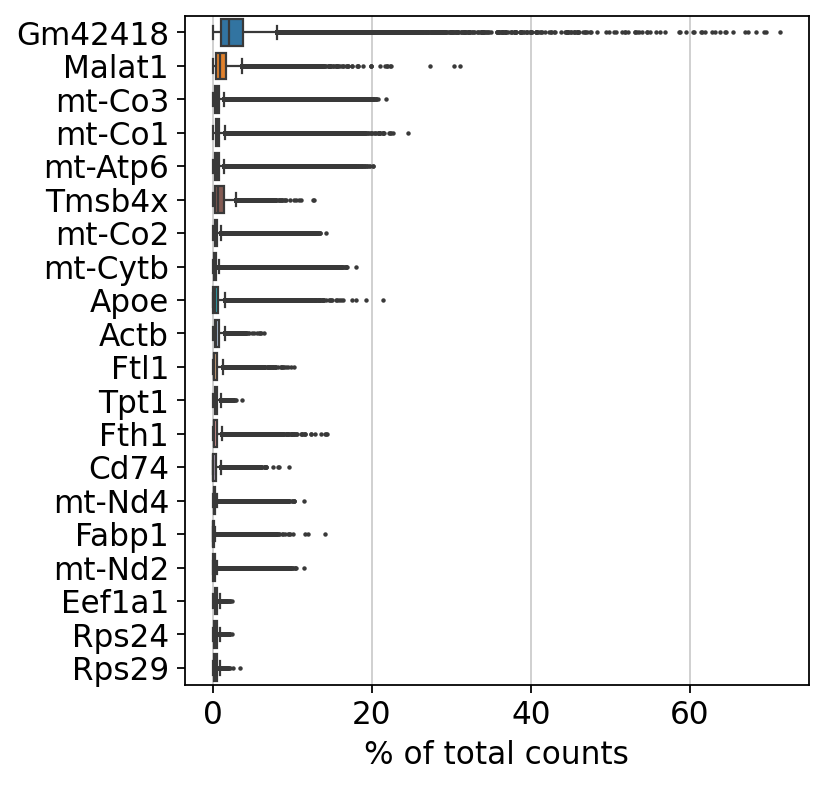

In [3]:
sc.pl.highest_expr_genes(adata, n_top=20)

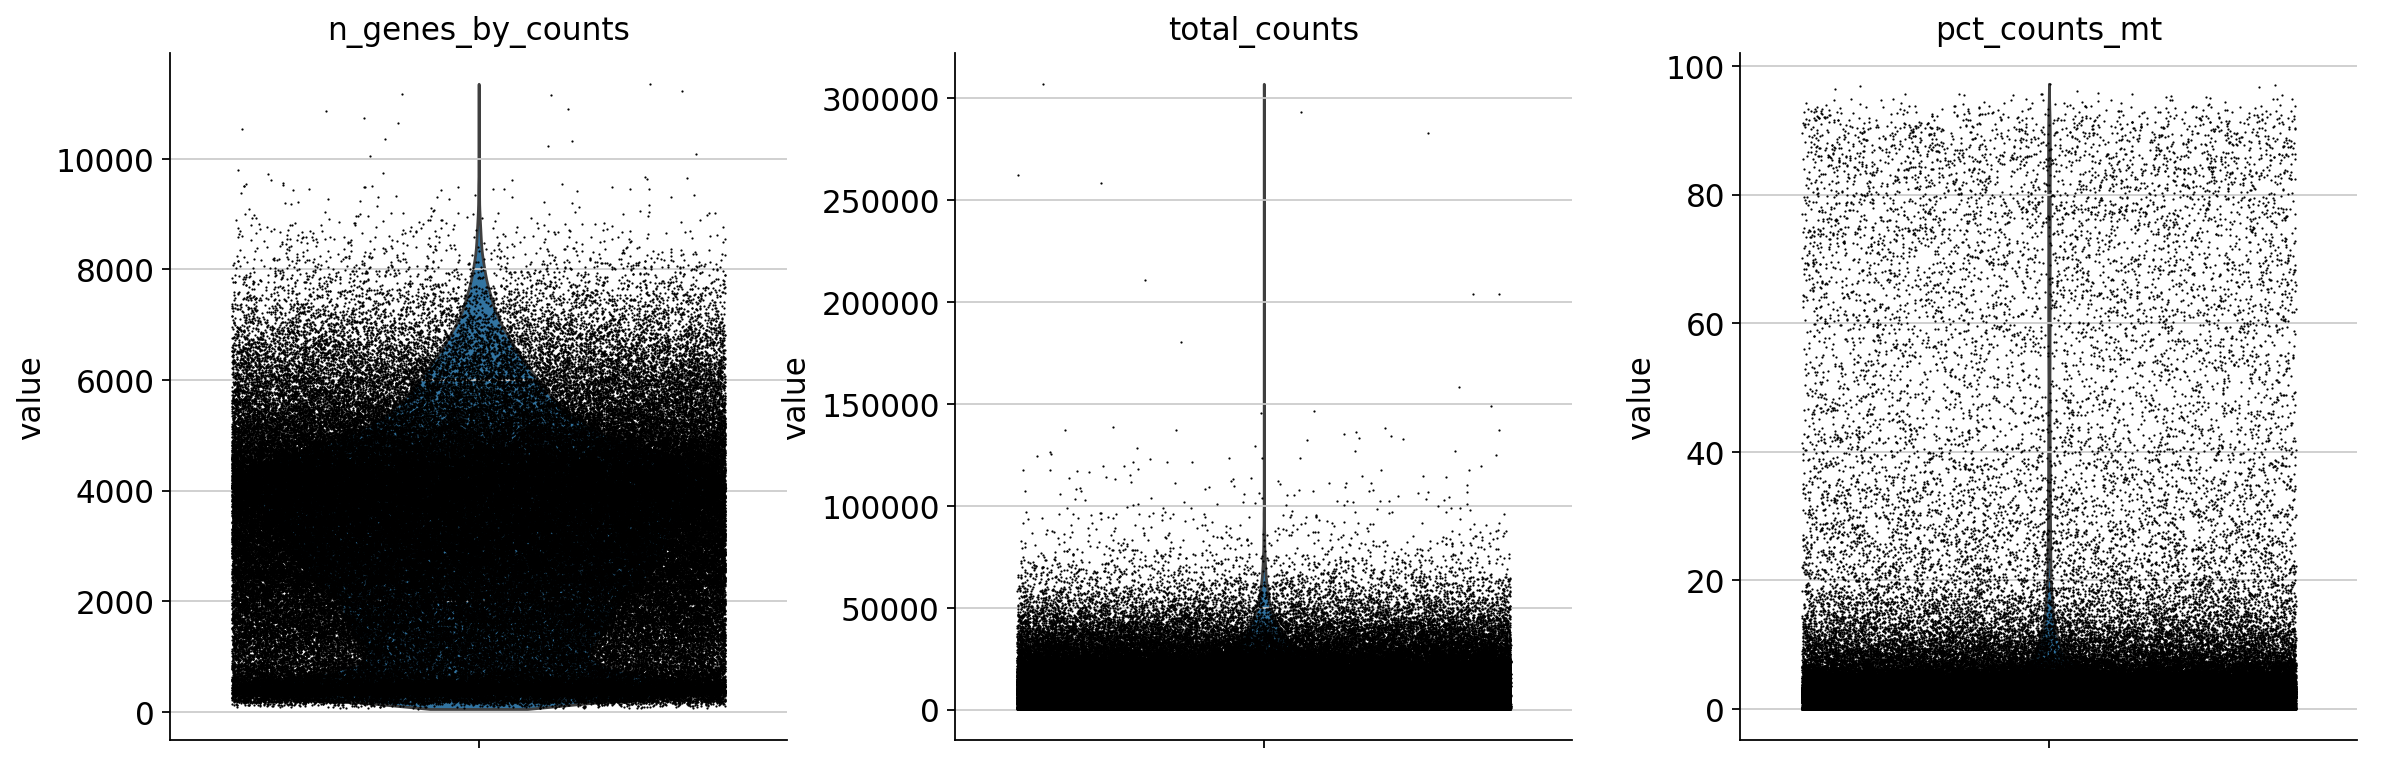

In [4]:
# annotate mitochondrial genes as 'mt' and calculate qc metrics
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
# plot a violin plot with some QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],jitter=0.4, multi_panel=True)

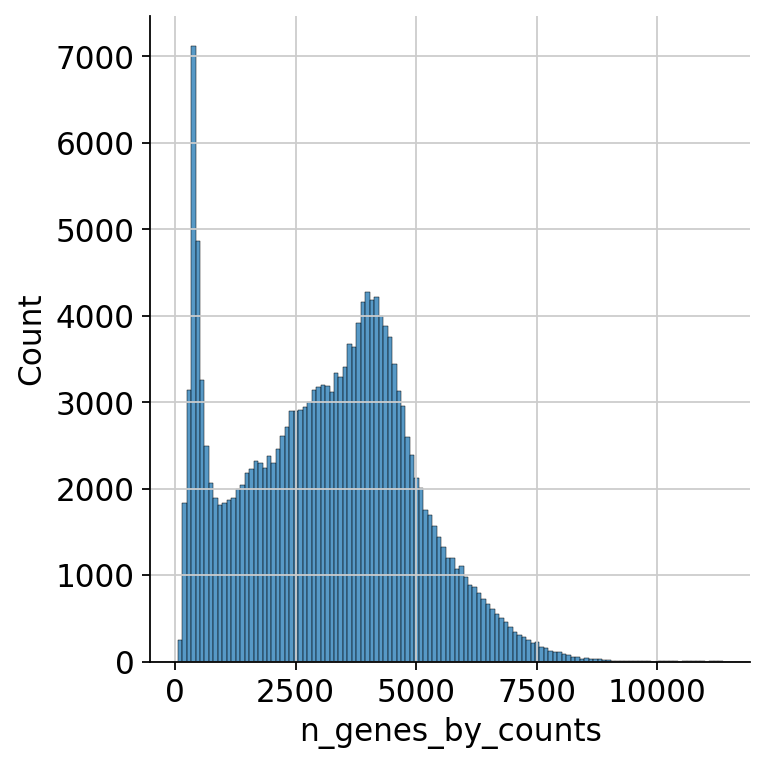

In [5]:
# plot a histograph of a single variable
sns.displot(adata.obs["n_genes_by_counts"])

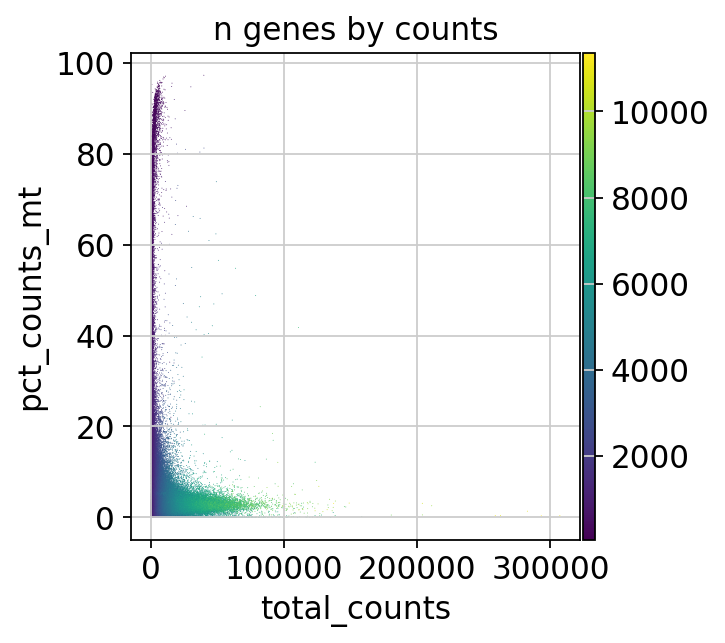

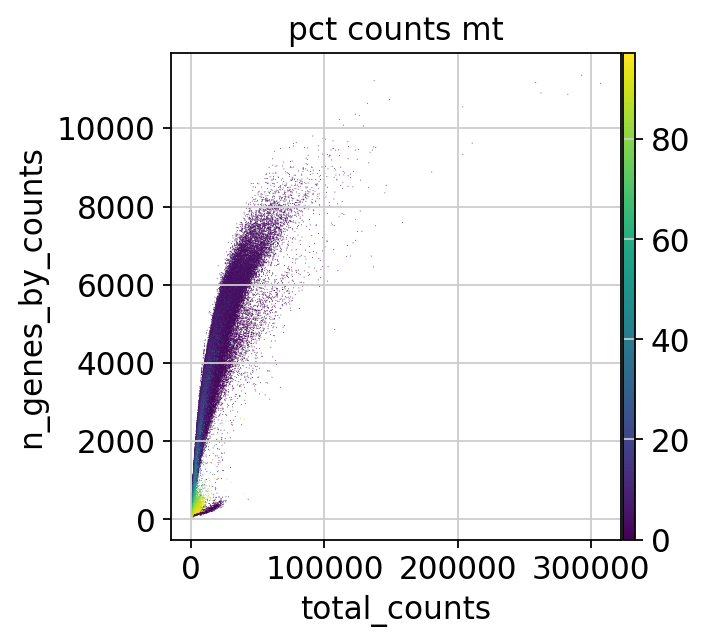

In [6]:
# plot a scatter plot of QC metrics
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', color = 'n_genes_by_counts')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color = 'pct_counts_mt')

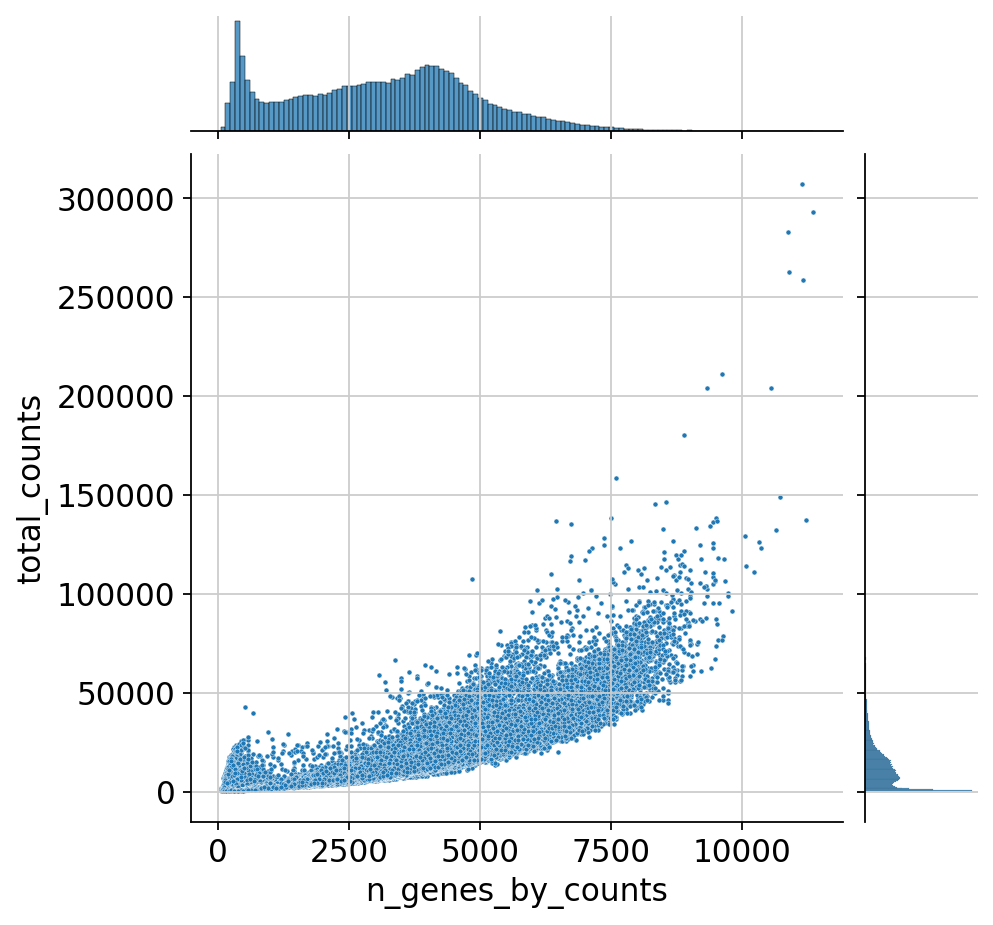

In [7]:
sns.jointplot(
    x="n_genes_by_counts",
    y="total_counts",
    data=adata.obs,
    kind="scatter",
    s=5
)

In [8]:
mito_gene_names = adata.var_names[adata.var['mt']]
print(f"Number of mitochondrial genes: {len(mito_gene_names)}")
print(mito_gene_names)
mito_adata = adata[:, mito_gene_names]
mito_counts = adata[:, adata.var['mt']].X.sum(axis=0)
mito_gene_counts = sorted(zip(mito_counts, adata.var_names[adata.var['mt']]), reverse=True)
print("Top 10 expressed mitochondrial genes:")
for count, gene in mito_gene_counts[:10]:
    print(f"{gene}: {count}")

Number of mitochondrial genes: 13
Index(['mt-Nd1', 'mt-Nd2', 'mt-Co1', 'mt-Co2', 'mt-Atp8', 'mt-Atp6', 'mt-Co3',
       'mt-Nd3', 'mt-Nd4l', 'mt-Nd4', 'mt-Nd5', 'mt-Nd6', 'mt-Cytb'],
      dtype='object')
Top 10 expressed mitochondrial genes:
mt-Nd1: [[ 4363467.  4387430. 15689277. 10555314.   274079. 13532543. 14335757.
   1083107.   667263.  5128940.  1130938.    91399.  7744039.]]


In [9]:
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize
sc.pp.log1p(adata)  # Log transform
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5) # Feature selection
# adata = adata[:, adata.var.highly_variable] # filter to variable genes.
sc.pp.scale(adata, max_value=10) # Scale
sc.tl.pca(adata, svd_solver='arpack') # PCA

normalizing counts per cell
    finished (0:00:05)
extracting highly variable genes
    finished (0:00:13)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:00:20)


In [10]:
adata

AnnData object with n_obs × n_vars = 183472 × 32285
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [11]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40) # Adjust n_neighbors and n_pcs as needed
sc.tl.leiden(adata)

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:55)
running Leiden clustering


/tmp/ipykernel_4165598/1066316764.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


    finished: found 58 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:01:18)


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:03:49)


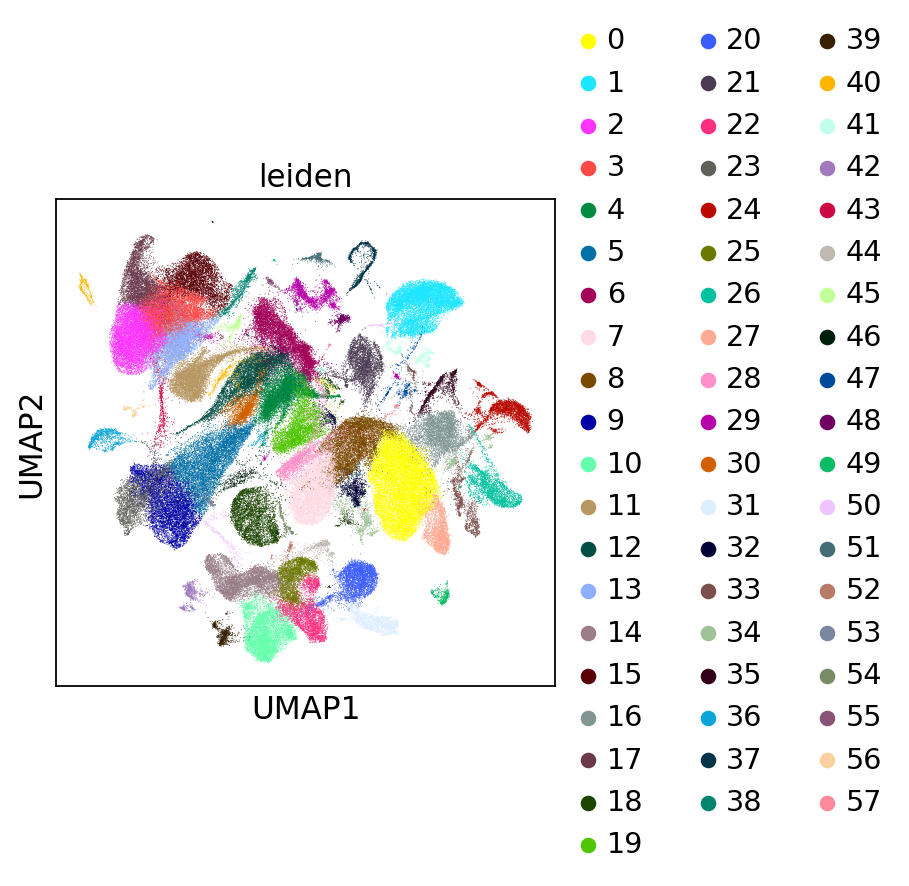

In [12]:
sc.tl.umap(adata) # or sc.tl.tsne(adata)
sc.pl.umap(adata, color=['leiden']) # or sc.pl.tsne(adata, color=['leiden'])

In [13]:
adata

AnnData object with n_obs × n_vars = 183472 × 32285
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [ ]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]  # Keep only highly variable genes

extracting highly variable genes


/home/gupta385/.local/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:74: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


In [ ]:
from scarches.models.scanvi import SCANVI

# Define model
scanvi = SCANVI(adata, unlabeled_category="Unknown")

# Train model (adjust epochs as needed)
scanvi.train(n_epochs=100)

# Annotate cells
adata.obs['scArches_annotation'] = scanvi.predict()

In [ ]:
adata.obs['scArches_annotation'].value_counts()
sc.pl.umap(adata, color='scArches_annotation')